In [85]:
!pip install pandas
!pip install numpy
!pip install matplotlib
!pip install seaborn
# !pip install ast

In [86]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
# from matplotlib.colors import ListedColormap5
import ast
import numpy as np
import os

%matplotlib inline

In [87]:
# Constants
MIN_5 = 320
MIN_10 = 620
MIN_15 = 1000
MIN_30 = 1820
MIN_60 = 3620
MIN_120 = 7220

# Color palette for classes
# {'Electro-mechanical', 'Geonature', 'Animal', 'Other human', 'Social/communal', 'Human movement', 'Music', 'Motorised transport', 'Voice', 'Other Sounds', 'Background'}
# LENGTH 11

COLLOR_PALLET = {
            'Electro-mechanical': '#cc0000', # RED
            'Geonature': '#8e7cc3', # PURPLE
            'Animal': '#9b5f00', # BROWN
            'Other human': '#2986cc', # BLUE
            'Social/communal': '#ffa500', # ORANGE
            'Human movement': '#6aa84f', # GREEN
            'Music': '#d172a4', # PINK
            'Motorised transport': '#d8cbf8', # LIGHT PURPLE
            'Voice': '#40b674', # LIGHT GREEN 
            'Other Sounds': '#a3c4eb', # LIGHT BLUE
            'Background': '#000000', # BLACK
        }

In [88]:
def extract_location(file_path):
    file_name = os.path.basename(file_path)
    
    if "TENERIFE" in file_name and "FREEOLSEN" in file_name:
        return "Tenerife, Fred Olsen"
    elif "TENERIFE" in file_name and "ARMAS" in file_name:
        return "Tenerife, Armas"
    elif "espolon" in file_name and "petronor" in file_name:
        return "Espolón Petronor"
    elif "BASURTO" in file_name or "basurto" in file_name:
        return "BASURTO"
    else:
        return "Unknown Location"

def remove_label(classes_list, label):
    return [x for x in classes_list if x != label]

def first_element(classes_list):
    return [classes_list[0]] if classes_list else []

def interval_printing(average_interval):
    if average_interval > 0 and average_interval < MIN_5:
        print(f"The average interval between each audio file is 5 minutes ({round(average_interval)} seconds, which are {round(average_interval/60)} minutes)")
    elif average_interval > MIN_5 and average_interval < MIN_10:
        print(f"The average interval between each audio file is 10 minutes ({round(average_interval)} seconds, which are {round(average_interval/60)} minutes)")
    elif average_interval > MIN_10 and average_interval < MIN_15:
        print(f"The average interval between each audio file is 15 minutes ({round(average_interval)} seconds, which are {round(average_interval/60)} minutes)")
    elif average_interval > MIN_15 and average_interval < MIN_30:
        print(f"The average interval between each audio file is 30 minutes ({round(average_interval)} seconds, which are {round(average_interval/60)} minutes)")
    elif average_interval > MIN_30 and average_interval < MIN_60:
        print(f"The average interval between each audio file is 60 minutes ({round(average_interval)} seconds), which are {round(average_interval/60)} minutes)")
    elif average_interval > MIN_60 and average_interval < MIN_120:
        print(f"The average interval between each audio file is 120 minutes ({round(average_interval)} seconds, which are {round(average_interval/60)} minutes)")

def insert_dates(df):
    df["year"] = df.index.year
    df["month"] = df.index.month
    df["day"] = df.index.day
    df["hour"] = df.index.hour
    df["minute"] = df.index.minute
    df["second"] = df.index.second
    df["weekday"] = df.index.day_name()

    weekday_translation = {
        "Monday": "Lunes",
        "Tuesday": "Martes",
        "Wednesday": "Miércoles",
        "Thursday": "Jueves",
        "Friday": "Viernes",
        "Saturday": "Sábado",
        "Sunday": "Domingo"
    }
    df["weekday"] = df["weekday"].replace(weekday_translation)
    df["weekday"] = df["weekday"].astype(str)
    df["day"] = df["day"].astype(str).str.zfill(2)
    df["fullday"] = df["day"] + "," + df["weekday"]

    return df

In [89]:
# tenerife_fred_olsen = "csv/avg_predictions_original_custom_10p_TENERIFE_FREEOLSEN.csv"
# tenerife_la_palma = "avg_predictions_original_custom_10p_LA_PALMA_ARMAS.csv"
espolon_petronor = "/home/aaccolombia/Documents/AAC/NoisePort/Noiseport/Audio_Processing/Test/yamnet_programs/results_20221026/10-probs/avg_predictions_original_custom_10espolon_petronor-20221006.csv"
torreta_petronor = "csv/avg_predictions_original_custom_10p_torreta_petronor-20221027.csv"
basurto_test ="/home/santi/Documents/AAC/audios/AudioMoths/OCIO/23079_BILBAO_MR_OCIO/BASURTO/Results/Urban_Model_BASURTO_3_pred.csv"

# df = pd.read_csv(tenerife_fred_olsen, sep=";")
# df = pd.read_csv("avg_predictions_original_custom_10p_LA_PALMA_ARMAS.csv")
# df = pd.read_csv(espolon_petronor)
# df = pd.read_csv(torreta_petronor)
df = pd.read_csv(basurto_test)

title = extract_location(basurto_test)

df

,files,datetime,classes_custom,probabilities_custom,sum_probs_custom,classes_original,probabilities_original,sum_probs_original
0,20231019_172005.WAV,2023-10-19 17:20:05,"['Voice', 'Animal', 'Motorised transport']","[0.3012570938949426, 0.25823251023614147, 0.11...",0.670181,"['Speech', 'Animal', 'Wild animals']","[0.29320621, 0.053196896, 0.041956093]",0.388359
1,20231019_173510.WAV,2023-10-19 17:35:10,"['Voice', 'Animal', 'Motorised transport']","[0.30417082604501744, 0.24525736378545643, 0.1...",0.666142,"['Speech', 'Animal', 'Wild animals']","[0.29281715, 0.050105717, 0.042705126]",0.385628
2,20231019_175015.WAV,2023-10-19 17:50:15,"['Voice', 'Animal', 'Motorised transport']","[0.2464110797559444, 0.1753065744179485, 0.171...",0.593140,"['Speech', 'Vehicle', 'Inside, small room']","[0.22410047, 0.066000834, 0.038165595]",0.328267
3,20231019_180520.WAV,2023-10-19 18:05:20,"['Motorised transport', 'Voice', 'Animal']","[0.2097017557705356, 0.20212835444623986, 0.14...",0.557943,"['Speech', 'Vehicle', 'Inside, small room']","[0.19955753, 0.08403904, 0.04377307]",0.327370
4,20231019_182025.WAV,2023-10-19 18:20:25,"['Motorised transport', 'Animal', 'Voice']","[0.22683770159753208, 0.16463615335462442, 0.1...",0.545265,"['Speech', 'Vehicle', 'Inside, small room']","[0.16615212, 0.101369165, 0.048920773]",0.316442
5,20231019_183530.WAV,2023-10-19 18:35:30,"['Motorised transport', 'Animal', 'Voice']","[0.20912972316026615, 0.17684084981543247, 0.1...",0.547937,"['Speech', 'Vehicle', 'Inside, small room']","[0.16782705, 0.08871669, 0.049903832]",0.306448
6,20231019_185035.WAV,2023-10-19 18:50:35,"['Voice', 'Motorised transport', 'Animal']","[0.20278207401721016, 0.18596610003475741, 0.1...",0.554934,"['Speech', 'Vehicle', 'Inside, small room']","[0.19567513, 0.07568589, 0.04992675]",0.321288
7,20231019_190540.WAV,2023-10-19 19:05:40,"['Voice', 'Motorised transport', 'Animal']","[0.2338257822851342, 0.1758770755498091, 0.159...",0.569249,"['Speech', 'Vehicle', 'Inside, small room']","[0.20894796, 0.067409, 0.043597627]",0.319955
8,20231019_192045.WAV,2023-10-19 19:20:45,"['Voice', 'Motorised transport', 'Animal']","[0.30890981231479564, 0.1647753859821812, 0.14...",0.615341,"['Speech', 'Vehicle', 'Inside, small room']","[0.26788524, 0.06048043, 0.033266943]",0.361633
9,20231019_193550.WAV,2023-10-19 19:35:50,"['Voice', 'Motorised transport', 'Animal']","[0.3526155821491911, 0.14136147933995952, 0.14...",0.634108,"['Speech', 'Vehicle', 'Inside, small room']","[0.28674483, 0.046614774, 0.030335903]",0.363696


In [90]:
print("We are working with {} processing results".format(len(df)))
print(f"We are working within the time range from [ {df['datetime'].min()} ] to [ {df['datetime'].max()} ]")

df['datetime'] = pd.to_datetime(df['datetime'])
time_difference_seconds = df['datetime'].diff().dt.total_seconds()
average_interval = time_difference_seconds.mean()
interval_printing(average_interval)

We are working with 20 processing results
We are working within the time range from [ 2023-10-19 17:20:05 ] to [ 2023-10-19 22:06:40 ]
The average interval between each audio file is 15 minutes (905 seconds, which are 15 minutes)


In [91]:
# convert string to list
df['classes_custom'] = df['classes_custom'].apply(ast.literal_eval)

print(f"Type of the column: \t\t {type(df['classes_custom'])}")
print(f"Type of the first element: \t\t {type(df['classes_custom'][0])}")

# df['classes_custom'] = df['classes_custom'].apply(lambda x: remove_label(x, 'Nature'))
# df['classes_custom'] = df['classes_custom'].apply(lambda x: remove_label(x, 'Voice'))

df['classes_custom']

Type of the column: 		 <class 'pandas.core.series.Series'>
Type of the first element: 		 <class 'list'>


0           [Voice, Animal, Motorised transport]
1           [Voice, Animal, Motorised transport]
2           [Voice, Animal, Motorised transport]
3           [Motorised transport, Voice, Animal]
4           [Motorised transport, Animal, Voice]
5           [Motorised transport, Animal, Voice]
6           [Voice, Motorised transport, Animal]
7           [Voice, Motorised transport, Animal]
8           [Voice, Motorised transport, Animal]
9           [Voice, Motorised transport, Animal]
10          [Voice, Animal, Motorised transport]
11          [Voice, Animal, Motorised transport]
12          [Voice, Animal, Motorised transport]
13          [Voice, Animal, Motorised transport]
14                   [Voice, Animal, Background]
15          [Voice, Motorised transport, Animal]
16    [Motorised transport, Voice, Other Sounds]
17          [Voice, Motorised transport, Animal]
18          [Voice, Animal, Motorised transport]
19          [Voice, Animal, Motorised transport]
Name: classes_custom

In [92]:
# print("Nature" in df['classes_custom'])
# print("Voice" in df['classes_custom'])

In [93]:
df['classes_custom'] = df['classes_custom'].apply(first_element)
df['classes_custom']

flatten_list = [item for sublist in df['classes_custom'] for item in sublist]
flatten_list

['Voice',
 'Voice',
 'Voice',
 'Motorised transport',
 'Motorised transport',
 'Motorised transport',
 'Voice',
 'Voice',
 'Voice',
 'Voice',
 'Voice',
 'Voice',
 'Voice',
 'Voice',
 'Voice',
 'Voice',
 'Motorised transport',
 'Voice',
 'Voice',
 'Voice']

In [94]:
print(f"These are the class count:\n\n{df['classes_custom'].value_counts()}")

print(f"\nThese are the class summed: \t\t {df['classes_custom'].value_counts().sum()}")
print(f"This is the lenght of the dataframe \t {len(df)}")

These are the class count:

classes_custom
[Voice]                  16
[Motorised transport]     4
Name: count, dtype: int64

These are the class summed: 		 20
This is the lenght of the dataframe 	 20


In [95]:
df['single_class'] = df['classes_custom'].apply(lambda x: x[0] if x else None)
df.set_index("datetime", inplace=True)
df = insert_dates(df)

In [96]:
df

,files,classes_custom,probabilities_custom,sum_probs_custom,classes_original,probabilities_original,sum_probs_original,single_class,year,month,day,hour,minute,second,weekday,fullday
datetime,,,,,,,,,,,,,,,,
2023-10-19 17:20:05,20231019_172005.WAV,[Voice],"[0.3012570938949426, 0.25823251023614147, 0.11...",0.670181,"['Speech', 'Animal', 'Wild animals']","[0.29320621, 0.053196896, 0.041956093]",0.388359,Voice,2023,10,19,17,20,5,Jueves,"19,Jueves"
2023-10-19 17:35:10,20231019_173510.WAV,[Voice],"[0.30417082604501744, 0.24525736378545643, 0.1...",0.666142,"['Speech', 'Animal', 'Wild animals']","[0.29281715, 0.050105717, 0.042705126]",0.385628,Voice,2023,10,19,17,35,10,Jueves,"19,Jueves"
2023-10-19 17:50:15,20231019_175015.WAV,[Voice],"[0.2464110797559444, 0.1753065744179485, 0.171...",0.593140,"['Speech', 'Vehicle', 'Inside, small room']","[0.22410047, 0.066000834, 0.038165595]",0.328267,Voice,2023,10,19,17,50,15,Jueves,"19,Jueves"
2023-10-19 18:05:20,20231019_180520.WAV,[Motorised transport],"[0.2097017557705356, 0.20212835444623986, 0.14...",0.557943,"['Speech', 'Vehicle', 'Inside, small room']","[0.19955753, 0.08403904, 0.04377307]",0.327370,Motorised transport,2023,10,19,18,5,20,Jueves,"19,Jueves"
2023-10-19 18:20:25,20231019_182025.WAV,[Motorised transport],"[0.22683770159753208, 0.16463615335462442, 0.1...",0.545265,"['Speech', 'Vehicle', 'Inside, small room']","[0.16615212, 0.101369165, 0.048920773]",0.316442,Motorised transport,2023,10,19,18,20,25,Jueves,"19,Jueves"
2023-10-19 18:35:30,20231019_183530.WAV,[Motorised transport],"[0.20912972316026615, 0.17684084981543247, 0.1...",0.547937,"['Speech', 'Vehicle', 'Inside, small room']","[0.16782705, 0.08871669, 0.049903832]",0.306448,Motorised transport,2023,10,19,18,35,30,Jueves,"19,Jueves"
2023-10-19 18:50:35,20231019_185035.WAV,[Voice],"[0.20278207401721016, 0.18596610003475741, 0.1...",0.554934,"['Speech', 'Vehicle', 'Inside, small room']","[0.19567513, 0.07568589, 0.04992675]",0.321288,Voice,2023,10,19,18,50,35,Jueves,"19,Jueves"
2023-10-19 19:05:40,20231019_190540.WAV,[Voice],"[0.2338257822851342, 0.1758770755498091, 0.159...",0.569249,"['Speech', 'Vehicle', 'Inside, small room']","[0.20894796, 0.067409, 0.043597627]",0.319955,Voice,2023,10,19,19,5,40,Jueves,"19,Jueves"
2023-10-19 19:20:45,20231019_192045.WAV,[Voice],"[0.30890981231479564, 0.1647753859821812, 0.14...",0.615341,"['Speech', 'Vehicle', 'Inside, small room']","[0.26788524, 0.06048043, 0.033266943]",0.361633,Voice,2023,10,19,19,20,45,Jueves,"19,Jueves"


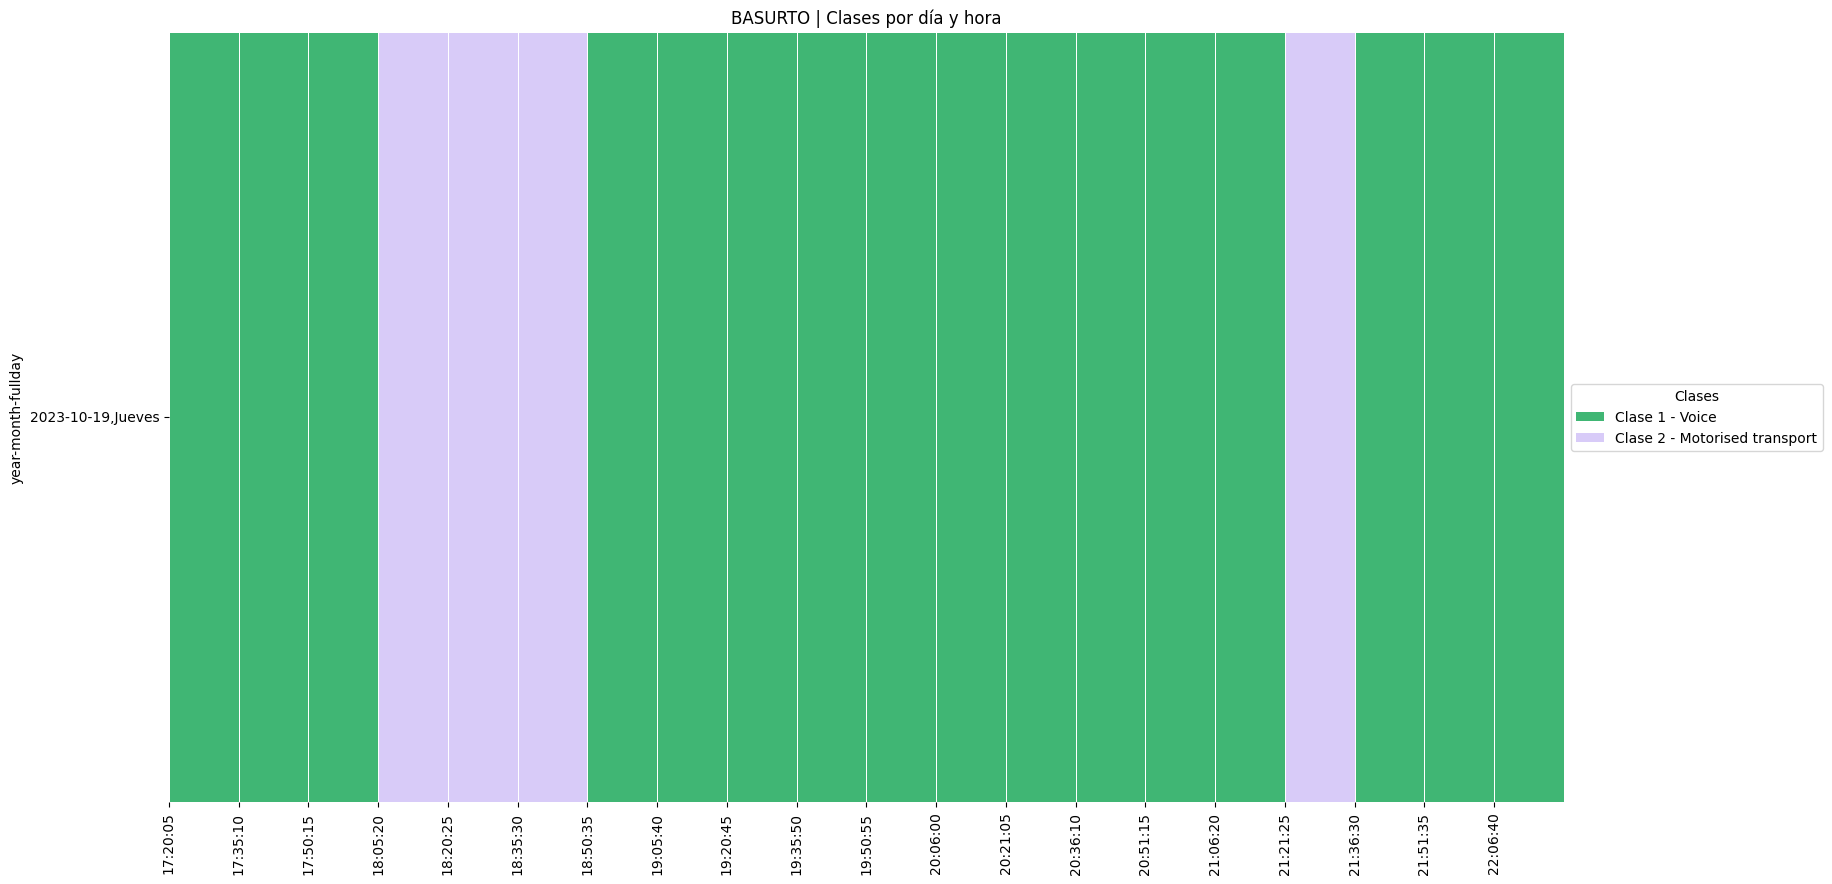

In [97]:
df = df.sort_values(by=["year", "month", "fullday"])

# map class to number
class_to_num = {class_name: index+1 for index, class_name in enumerate(df['single_class'].unique())}
df['class_num'] = df['single_class'].map(class_to_num)

# inverting the dictionary to get the name of the class for the legend
name_class = {v: k for k, v in class_to_num.items()}

# mapping from classes numbers to colors
num_to_color = {num: COLLOR_PALLET[class_name] for class_name, num in class_to_num.items()}
cmap = [num_to_color[cls_num] for cls_num in name_class.keys()]

# legend_colors = sns.color_palette("husl", n_colors=len(name_class))
# cmap = sns.color_palette(legend_colors, n_colors=len(name_class))
# legend_elements = [Patch(facecolor=color, label=f"Clase {cls_num} - {name_class.get(cls_num, '')}") for cls_num, color in zip(name_class.keys(), cmap)]

# leggend elements colors
legend_elements = [Patch(facecolor=num_to_color[cls_num], label=f"Clase {cls_num} - {name_class.get(cls_num, '')}") for cls_num in name_class.keys()]

day_class = pd.pivot_table(data=df, columns=df.index.time, index=["year", "month", "fullday"], values="class_num", aggfunc='mean')

plt.figure(figsize=(18, 10))

if day_class.isna().all().all() or day_class.empty:
    print("No valid data. Skipping...")
    
else:
    ax = sns.heatmap(day_class, annot=False, cmap=cmap, linewidth=0.5, cbar=False)
    
    ax.set_xticks(range(len(day_class.columns)))
    ax.set_xticklabels([t.strftime('%H:%M:%S') for t in day_class.columns], rotation=90)
    
    yticklabels = [f"{idx[0]}-{idx[1]}-{idx[2]}" for idx in day_class.index]
    ax.set_yticklabels(yticklabels, rotation=0)
    
    plt.legend(handles=legend_elements, title="Clases", loc='center left', bbox_to_anchor=(1, 0.5))
    plt.title(f"{title} | Clases por día y hora")
    plt.plot()

plt.show()

In [98]:
day = "29"

# Filter for the specific day across all years and months
df_xth = df[df["fullday"].str.startswith(day)]

if df_xth.empty:
    print(f"No data for the {day}th day across all years and months. Skipping...")
else:
    plt.figure(figsize=(20, 10))
    
    # Pivot with year and month as multi-index
    day_class = pd.pivot_table(data=df_xth, columns=df_xth.index.time, index=["year", "month"], values="class_num", aggfunc=lambda x: x.mode()[0] if not x.empty else None)
    
    if day_class.isna().all().all() or day_class.empty:
        print(f"No valid data for the {day}th day. Skipping...")
    else:
        unique_classes = day_class.dropna().values.flatten()
        unique_classes = set(unique_classes)
        
        current_legend_elements = [Patch(facecolor=cmap[int(cls_num)-1], label=f"Clase {cls_num} - {clase_nombres[cls_num]}") for cls_num in unique_classes]
        ax = sns.heatmap(day_class, annot=False, cmap=cmap, linewidth=0.5, cbar=False, vmin=1, vmax=len(clase_nombres))
        ax.set_xticklabels(ax.get_xticklabels(), rotation=90)
        
        # Remove the y-tick labels (to hide year and month labels on y-axis)
        ax.yaxis.set_visible(False)
        
        # Update title to include year, month, and day
        years = "-".join(map(str, df_xth["year"].unique()))
        months = "-".join(map(str, sorted(df_xth["month"].unique())))
        plt.legend(handles=current_legend_elements, title="Clases", loc='center left', bbox_to_anchor=(1, 0.5))
        plt.title(f"{title} | Data for {years}-{months}-{day}")

        plt.show()

No data for the 29th day across all years and months. Skipping...


In [99]:
day = "29"

for year in sorted(df["year"].unique()):
    df_year = df[df["year"] == year]
    for month in sorted(df_year["month"].unique()):
        df_temp = df_year[df_year["month"] == month]
        
        df_xth = df_temp[df_temp["fullday"].str.startswith(day)]
        
        start_time = pd.to_datetime("13:18:00").time()
        end_time = pd.to_datetime("16:04:00").time()
        time_mask = (df_xth.index.time >= start_time) & (df_xth.index.time <= end_time)
        df_xth_filtered = df_xth[time_mask]
        
        if df_xth_filtered.empty:
            print(f"No data for the {day}th day in Year: {year}, Month: {month} within the specified time range. Skipping...")
            continue
        
        plt.figure(figsize=(18, 10))
        
        day_class = pd.pivot_table(data=df_xth_filtered, columns=df_xth_filtered.index.time, index="fullday", values="class_num", aggfunc=lambda x: x.mode()[0] if not x.empty else None)
        
        if day_class.isna().all().all() or day_class.empty:
            print(f"No valid data for Year: {year}, Month: {month}, Day: {day} within the specified time range. Skipping...")
            continue
        
        unique_classes = day_class.dropna().values.flatten()
        unique_classes = set(unique_classes)
        
        current_legend_elements = [Patch(facecolor=cmap[int(cls_num)-1], label=f"Clase {cls_num} - {clase_nombres[cls_num]}") for cls_num in unique_classes]
        ax = sns.heatmap(day_class, annot=False, cmap=cmap, linewidth=0.5, cbar=False, vmin=1, vmax=len(clase_nombres))
        ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
        
        # Completely hide the y-axis
        ax.yaxis.set_visible(False)
        
        plt.legend(handles=current_legend_elements, title="Clases", loc='center left', bbox_to_anchor=(1, 0.5))
        plt.title(f"{title} | Data for {year}-{month}-{day} within {start_time} to {end_time}")

        plt.show()


No data for the 29th day in Year: 2023, Month: 10 within the specified time range. Skipping...
